Enlace notebook editable:

https://colab.research.google.com/drive/1sfVCmyBLl-VncFaLlrPkL9_EsTclMZNM?usp=sharing

# Paso 1: Generación de datos

In [ ]:
import pandas as pd
import numpy as np

## Opción 1: Mínimo aceptable

In [ ]:
# 1. Configuración inicial
np.random.seed(42) # Para reproducibilidad (que siempre genere los mismos datos)
num_registros = 5000 # 5000 registros es un excelente tamaño para entrenar el MVP

# 2. Generación de características base (features)

# Asignamos 60% casas y 40% departamentos
tipo_inmueble = np.random.choice(['Casa', 'Departamento'], size=num_registros, p=[0.6, 0.4])

# La cantidad de equipos depende del tipo de inmueble (lógica de negocio)
cantidad_equipos = np.where(tipo_inmueble == 'Casa',
                            np.random.randint(8, 25, num_registros),  # Casa: 8 a 24 equipos
                            np.random.randint(4, 15, num_registros))  # Departamento: 4 a 14 equipos

# Horas de alto consumo (entre 2 y 12 horas al día)
horas_alto_consumo = np.random.randint(2, 13, num_registros)

# Uso en horario pico (probabilidad del 65% de que sí lo usen)
uso_horario_pico = np.random.choice([True, False], size=num_registros, p=[0.65, 0.35])

# 3. Simulación del consumo eléctrico (kWh)

# Un consumo base lógico según el tamaño del lugar
consumo_base = np.where(tipo_inmueble == 'Casa', 200, 100)

# El consumo real es afectado por los equipos, las horas de uso y el horario pico
consumo_kwh = consumo_base + (cantidad_equipos * 18) + (horas_alto_consumo * 12)
consumo_kwh = consumo_kwh + np.where(uso_horario_pico, 45, 0) # Penalización si usa en hora pico

# Agregamos ruido gaussiano para que no sea un cálculo matemático perfecto
consumo_kwh = consumo_kwh + np.random.normal(0, 25, num_registros)
consumo_kwh = np.clip(consumo_kwh, 50, 1500).astype(int) # Mantenemos valores lógicos

# 4. Lógica de etiquetado (ground truth)

# Calculamos un "score de ineficiencia" interno para clasificar
# Comparamos el consumo real vs un "consumo ideal" para esa cantidad de equipos
consumo_ideal = consumo_base + (cantidad_equipos * 12) + 20
ratio_ineficiencia = consumo_kwh / consumo_ideal

score = (ratio_ineficiencia * 40) + (horas_alto_consumo * 2) + np.where(uso_horario_pico, 15, 0)
score += np.random.normal(0, 6, num_registros) # El "ruido" clave para Machine Learning

# Definimos los umbrales de las categorías
condiciones = [
    (score < 55),
    (score >= 55) & (score < 78),
    (score >= 78)
]
categorias = ['Eficiente', 'Moderado', 'Ineficiente']
categoria = np.select(condiciones, categorias, default='Desconocido')

# 5. Creación del DataFrame

df = pd.DataFrame({
    'consumo_kwh': consumo_kwh,
    'uso_horario_pico': uso_horario_pico,
    'cantidad_equipos': cantidad_equipos,
    'tipo_inmueble': tipo_inmueble,
    'horas_alto_consumo': horas_alto_consumo,
    'categoria': categoria
})

# 6. Mostrar resumen y guardar archivo

print("Distribución de categorías generadas:")
print(df['categoria'].value_counts(normalize=True) * 100)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

# Exportar a CSV para que se pueda descargar
df.to_csv('dataset_consumo_energia_G9_T60_opcion1.csv', index=False)
print("\n¡Archivo 'dataset_consumo_energia_G9_T60_opcion1.csv' generado con éxito!")

Distribución de categorías generadas:
categoria
Ineficiente    64.60
Moderado       31.02
Eficiente       4.38
Name: proportion, dtype: float64

Primeras 5 filas del dataset:


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,611,False,15,Casa,11,Ineficiente
1,354,False,8,Departamento,9,Ineficiente
2,449,False,13,Departamento,10,Ineficiente
3,616,True,13,Casa,11,Ineficiente
4,646,True,18,Casa,7,Ineficiente



¡Archivo 'dataset_consumo_energia_G9_T60_opcion1.csv' generado con éxito!


## Opción 2: Incluyendo regiones

In [ ]:
# 1. Configuración inicial
np.random.seed(42) # Para reproducibilidad (que siempre genere los mismos datos)
num_registros = 5000 # 5000 registros es un excelente tamaño para entrenar el MVP

# 2. Generación de características base (features)

# Asignamos 60% casas y 40% departamentos
tipo_inmueble = np.random.choice(['Casa', 'Departamento'], size=num_registros, p=[0.6, 0.4])

# --- NUEVA COLUMNA: REGIÓN ---
# Asumimos una distribución poblacional lógica (ej. 60% vive en el Centro)
region = np.random.choice(['Norte', 'Centro', 'Sur'], size=num_registros, p=[0.2, 0.6, 0.2])
# ---  ---

# La cantidad de equipos depende del tipo de inmueble (lógica de negocio)
cantidad_equipos = np.where(tipo_inmueble == 'Casa',
                            np.random.randint(8, 25, num_registros),  # Casa: 8 a 24 equipos
                            np.random.randint(4, 15, num_registros))  # Departamento: 4 a 14 equipos

# Horas de alto consumo (entre 2 y 12 horas al día)
horas_alto_consumo = np.random.randint(2, 13, num_registros)

# Uso en horario pico (probabilidad del 65% de que sí lo usen)
uso_horario_pico = np.random.choice([True, False], size=num_registros, p=[0.65, 0.35])

# 3. Simulación del consumo eléctrico (kWh)

# Un consumo base lógico según el tamaño del lugar
consumo_base = np.where(tipo_inmueble == 'Casa', 200, 100)

# --- NUEVA LÓGICA: AJUSTE CLIMÁTICO ---
# Sumamos kWh extra al consumo base por necesidad de climatización
ajuste_clima = np.select(
    [region == 'Norte', region == 'Sur'],
    [40, 60], # +40 kWh por AC en el Norte, +60 kWh por calefacción en el Sur
    default=0 # El Centro se queda igual
)
consumo_base = consumo_base + ajuste_clima
# ---  ---

# El consumo real es afectado por los equipos, las horas de uso y el horario pico
consumo_kwh = consumo_base + (cantidad_equipos * 18) + (horas_alto_consumo * 12)
consumo_kwh = consumo_kwh + np.where(uso_horario_pico, 45, 0) # Penalización si usa en hora pico

# Agregamos ruido gaussiano para que no sea un cálculo matemático perfecto
consumo_kwh = consumo_kwh + np.random.normal(0, 25, num_registros)
consumo_kwh = np.clip(consumo_kwh, 50, 1500).astype(int) # Mantenemos valores lógicos

# 4. Lógica de etiquetado (ground truth)

# Calculamos un "score de ineficiencia" interno para clasificar
# Comparamos el consumo real vs un "consumo ideal" para esa cantidad de equipos
consumo_ideal = consumo_base + (cantidad_equipos * 12) + 20
ratio_ineficiencia = consumo_kwh / consumo_ideal

score = (ratio_ineficiencia * 40) + (horas_alto_consumo * 2) + np.where(uso_horario_pico, 15, 0)
score += np.random.normal(0, 6, num_registros) # El "ruido" clave para Machine Learning

# Definimos los umbrales de las categorías
condiciones = [
    (score < 55),
    (score >= 55) & (score < 78),
    (score >= 78)
]
categorias = ['Eficiente', 'Moderado', 'Ineficiente']
categoria = np.select(condiciones, categorias, default='Desconocido')

# 5. Creación del DataFrame

df = pd.DataFrame({
    'consumo_kwh': consumo_kwh,
    'uso_horario_pico': uso_horario_pico,
    'cantidad_equipos': cantidad_equipos,
    'tipo_inmueble': tipo_inmueble,
    'horas_alto_consumo': horas_alto_consumo,
    'categoria': categoria,
    'region': region
})

# 6. Mostrar resumen y guardar archivo

print("Distribución de categorías generadas:")
print(df['categoria'].value_counts(normalize=True) * 100)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

# Exportar a CSV para que se pueda descargar
df.to_csv('dataset_consumo_energia_G9_T60_opcion2.csv', index=False)
print("\n¡Archivo 'dataset_consumo_energia_G9_T60_opcion2.csv' generado con éxito!")

Distribución de categorías generadas:
categoria
Ineficiente    63.26
Moderado       31.86
Eficiente       4.88
Name: proportion, dtype: float64

Primeras 5 filas del dataset:


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria,region
0,421,False,11,Casa,2,Moderado,Centro
1,309,False,5,Departamento,12,Ineficiente,Centro
2,390,True,11,Departamento,2,Moderado,Sur
3,759,True,21,Casa,12,Ineficiente,Centro
4,755,True,21,Casa,8,Ineficiente,Sur



¡Archivo 'dataset_consumo_energia_G9_T60_opcion2.csv' generado con éxito!


# Paso 2: Análisis exploratorio de datos (EDA)

In [ ]:
import pandas as pd
import numpy as np

print("="*50)
print(" 1. RESUMEN GENERAL Y SALUD DEL DATASET")
print("="*50)
print(f"Total de registros: {len(df)}")
print(f"Valores nulos por columna:\n{df.isnull().sum()}\n")

print("="*50)
print(" 2. ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS)")
print("="*50)
display(df.describe().T)

print("="*50)
print(" 3. CONSUMO PROMEDIO POR TIPO DE INMUEBLE Y REGIÓN")
print("="*50)
# Tabla pivote para cruzar Consumo promedio por Inmueble y Región
pivote_consumo = df.pivot_table(
    index='tipo_inmueble',
    columns='region',
    values='consumo_kwh',
    aggfunc=['mean', 'median']
).round(1)
display(pivote_consumo)

print("="*50)
print(" 4. CARACTERÍSTICAS PROMEDIO SEGÚN LA CATEGORÍA DE EFICIENCIA")
print("="*50)
# Agrupamos por categoría para ver qué diferencia a una vivienda 'Eficiente' de una 'Ineficiente'
resumen_categoria = df.groupby('categoria').agg(
    cant_viviendas=('consumo_kwh', 'count'),
    consumo_promedio=('consumo_kwh', 'mean'),
    equipos_promedio=('cantidad_equipos', 'mean'),
    horas_alto_consumo_prom=('horas_alto_consumo', 'mean'),
    pct_uso_horario_pico=('uso_horario_pico', lambda x: f"{x.mean()*100:.1f}%")
).reset_index()

display(resumen_categoria)

 1. RESUMEN GENERAL Y SALUD DEL DATASET
Total de registros: 5000
Valores nulos por columna:
consumo_kwh           0
uso_horario_pico      0
cantidad_equipos      0
tipo_inmueble         0
horas_alto_consumo    0
categoria             0
region                0
dtype: int64

 2. ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS)


,count,mean,std,min,25%,50%,75%,max
consumo_kwh,5000.0,530.1906,147.924928,149.0,415.0,521.0,649.0,909.0
cantidad_equipos,5000.0,13.2534,5.545605,4.0,9.0,12.0,17.0,24.0
horas_alto_consumo,5000.0,6.9568,3.127441,2.0,4.0,7.0,10.0,12.0


 3. CONSUMO PROMEDIO POR TIPO DE INMUEBLE Y REGIÓN


mean               median              
region        Centro  Norte    Sur Centro  Norte    Sur
tipo_inmueble                                          
Casa           600.4  646.3  661.6  603.0  647.0  667.0
Departamento   374.7  414.1  430.0  372.5  416.0  430.0

 4. CARACTERÍSTICAS PROMEDIO SEGÚN LA CATEGORÍA DE EFICIENCIA


,categoria,cant_viviendas,consumo_promedio,equipos_promedio,horas_alto_consumo_prom,pct_uso_horario_pico
0,Eficiente,244,441.147541,12.405738,3.106557,0.8%
1,Ineficiente,3163,547.680999,13.085678,8.227632,83.7%
2,Moderado,1593,509.101067,13.716259,5.023227,36.8%


/tmp/ipykernel_1768/2043711825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria', y='consumo_kwh', order=['Eficiente', 'Moderado', 'Ineficiente'], ax=axes[0], palette='coolwarm')


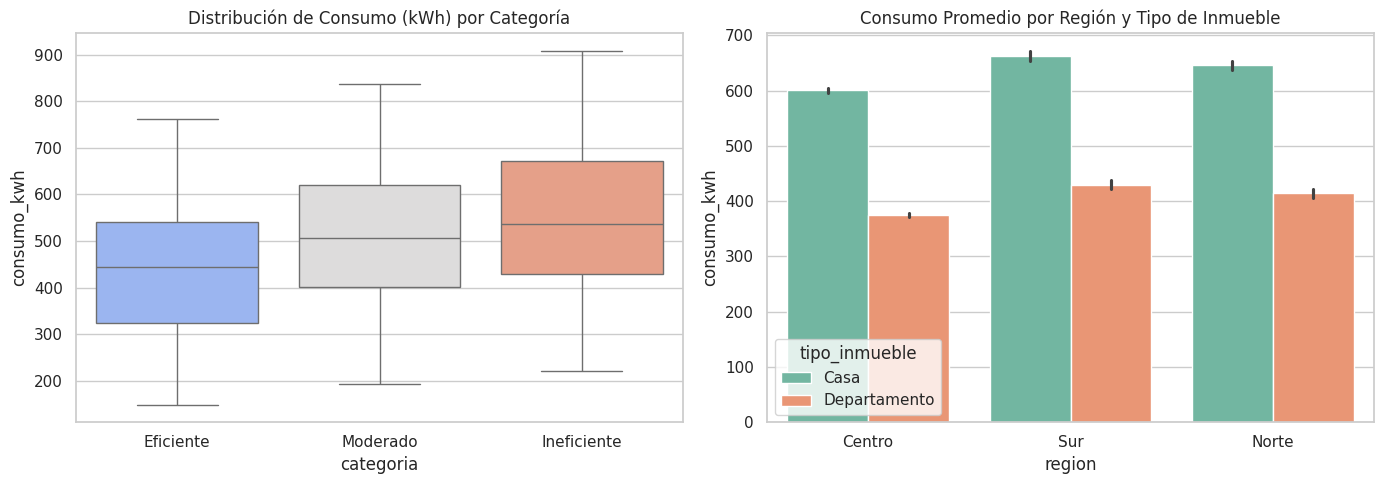

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución del consumo de kWh por Categoría
sns.boxplot(data=df, x='categoria', y='consumo_kwh', order=['Eficiente', 'Moderado', 'Ineficiente'], ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribución de Consumo (kWh) por Categoría', fontsize=12)

# Gráfico 2: Consumo promedio por Región e Inmueble
sns.barplot(data=df, x='region', y='consumo_kwh', hue='tipo_inmueble', ax=axes[1], palette='Set2')
axes[1].set_title('Consumo Promedio por Región y Tipo de Inmueble', fontsize=12)

plt.tight_layout()
plt.show()

# Paso 3: Análisis de patrones de consumo

# Paso 4: Procesamiento y transformación de variables

# Paso 5: Entrenamiento de modelos supervisados

# Paso 6: Evaluación utilizando métricas adecuadas

# Paso 7: Generación de recomendaciones basadas en reglas o modelos

# Paso 8: Serialización del modelo entrenado